# wta2d Package Demo

This notebook tests the **wta2d** package: 2D Winner-Take-All neural networks (Python port of the Matlab `WTA_2D_*` scripts).

## 1. Import and version

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import wta2d
print(f"wta2d version: {wta2d.__version__}")

wta2d version: 0.1.0


## 2. High-level run (like Matlab script)

Short simulation with default parameters; then plot summary and kernels.

In [28]:
xs, Inp, We, Wi, aa = wta2d.run(side=20, tlen=3000)
print(f"Grid: {aa}x{aa} = {aa*aa} neurons, {xs.shape[0]} time steps")

Grid: 20x20 = 400 neurons, 3000 time steps


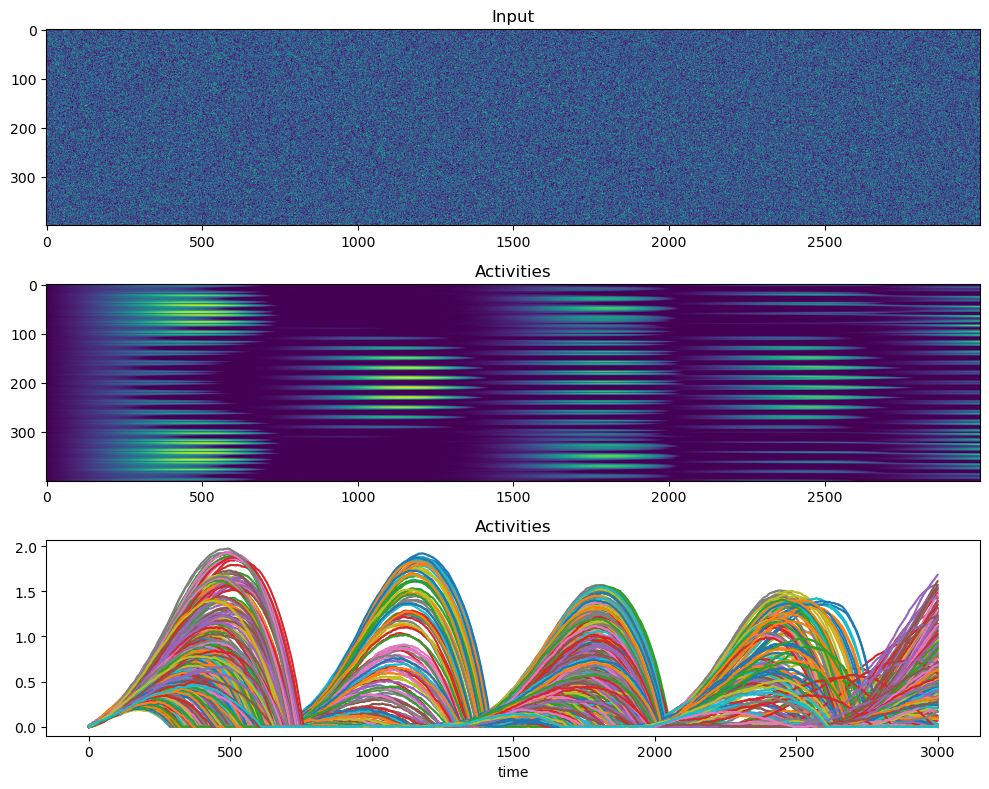

In [29]:
wta2d.plot_summary(xs, Inp)
plt.gcf().set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [31]:
import imageio
try:
    wta2d.save_gif(xs, aa, 'wta2d_activity2.gif', nframe=30, delay=0.1)
    print('Saved Examples/wta2d_activity2.gif')
except ImportError as e:
    print('GIF export needs imageio:', e)

Saved wta2d_activity2.gif


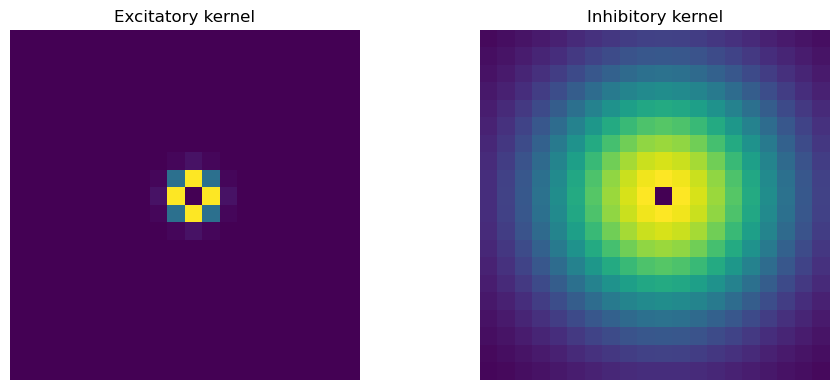

In [4]:
wta2d.plot_kernels(We, Wi, aa)
plt.show()

## 3. Modular usage

Build grid, kernels, custom input, then simulate step-by-step.

Activity shape: (5000, 1600), max activity: 1.569


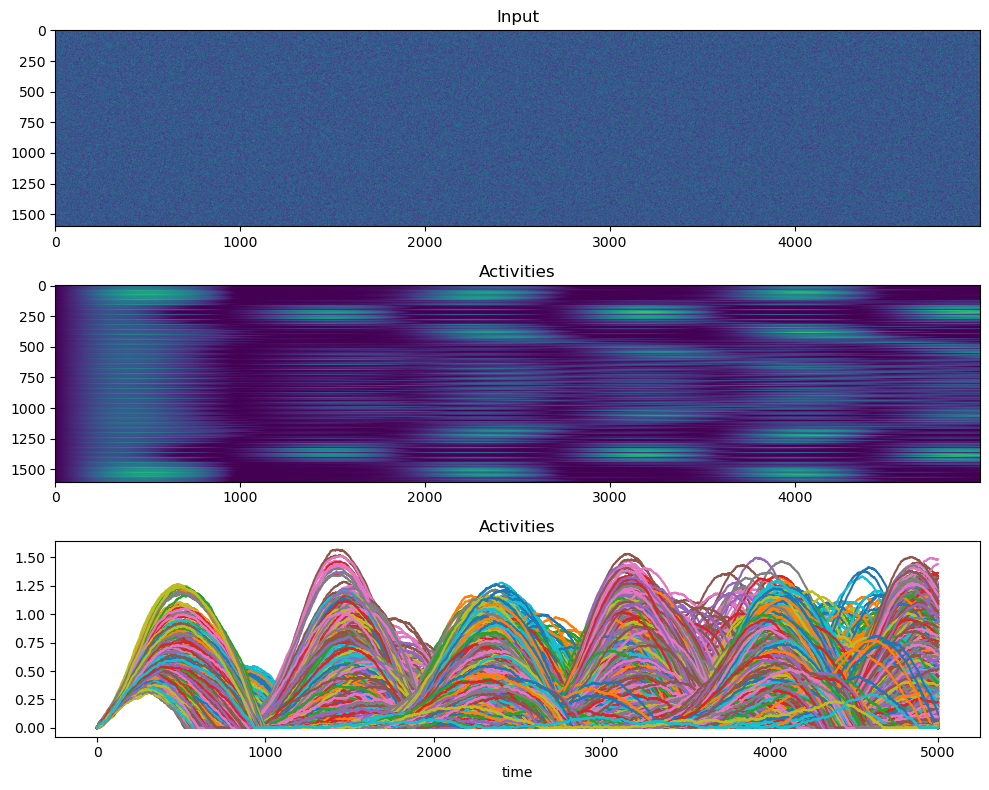

In [70]:
from wta2d import make_grid, make_weights, simulate, random_sparse_input

aa = 40
side = aa
tlen = 5000
N, pos, distan = make_grid(side)
We, Wi = make_weights(distan, Ae=0.6, ke=1.0, Ai=0.1, ki=4)
Inp = random_sparse_input(tlen, N, sparsity=0.55, rng=np.random.default_rng(1))
xs = simulate(We, Wi, Inp, h=0.001, B=10, C=2, recov=0.7, rstrength=0.9)
print(f"Activity shape: {xs.shape}, max activity: {xs.max():.3f}")

wta2d.plot_summary(xs, Inp, title_activities="Activities")
plt.show()

wta2d.save_gif(xs, aa, 'wta2d_activity6.gif', nframe=40, delay=0.1)


## 4. Strip input (pattern that turns off halfway)

Reproduces the WTA_2D_pattern6 / pattern8 style: input on a strip of neurons, then shut off.

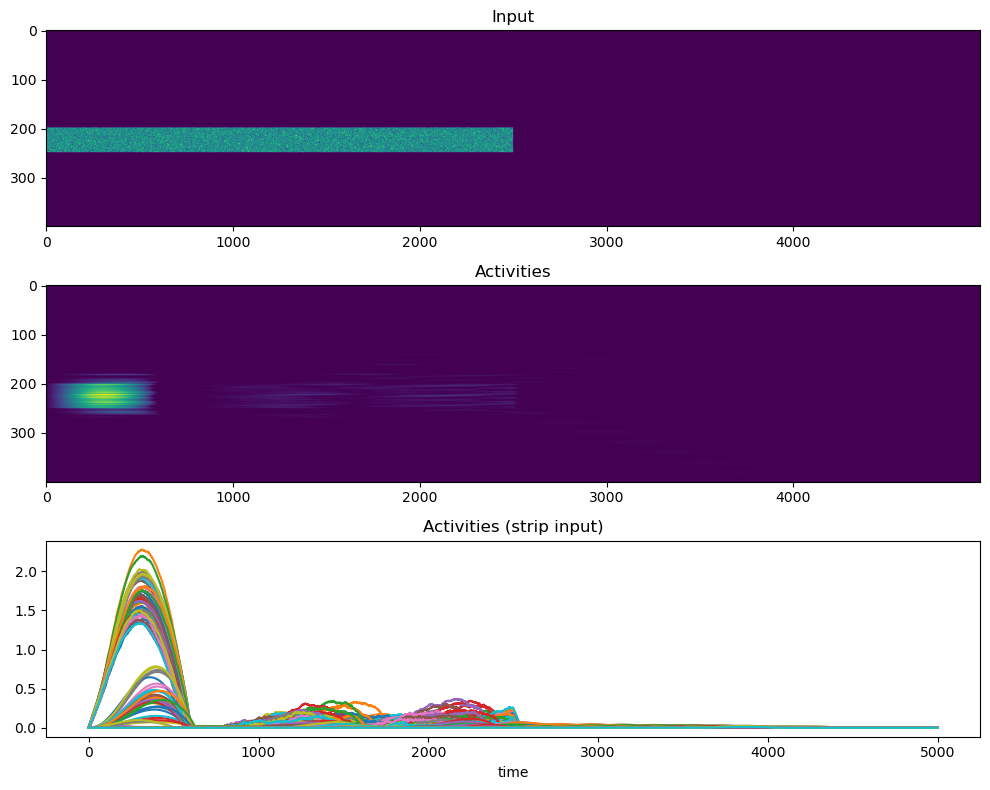

In [ ]:
xs_strip, Inp_strip, We_s, Wi_s, aa_s = wta2d.run_pattern_strip(
    side=20, tlen=5000, strip=(200, 250), turn_off_frac=0.5
)
wta2d.plot_summary(xs_strip, Inp_strip, title_activities="Activities (strip input)")
plt.show()

## 5. Interactive time slider (show_2d)

Run the cell below to open an interactive figure: use the slider to scrub through time and view input vs activity as 2D grids.

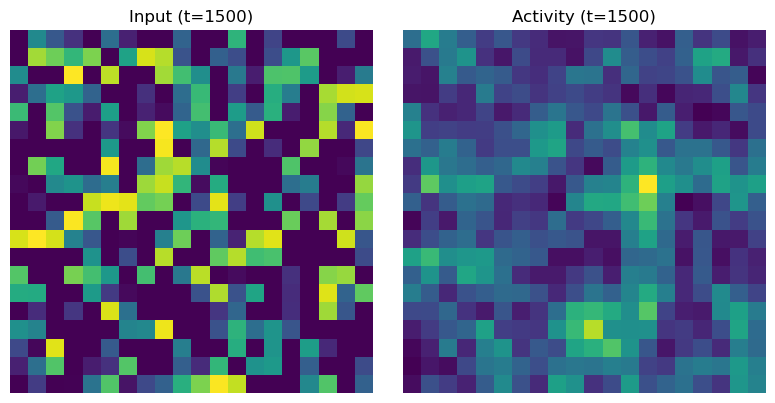

In [27]:
# Uncomment to run in a context where a GUI is available:
#wta2d.show_2d(xs, Inp, aa)

# Or plot a single time step (works in headless/notebook):
import matplotlib.pyplot as plt
t_idx = min(1500, xs.shape[0] - 1)  # stay in range
aa_plot = int(np.sqrt(xs.shape[1]))  # grid size from current data
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Inp[t_idx].reshape(aa_plot, aa_plot), aspect='equal')
axes[0].set_title('Input (t={})'.format(t_idx))
axes[0].axis('off')
axes[1].imshow(xs[t_idx].reshape(aa_plot, aa_plot), aspect='equal')
axes[1].set_title('Activity (t={})'.format(t_idx))
axes[1].axis('off')
plt.tight_layout()
plt.show()

c:\Users\yohan\Cursor\Netwhirl\Netwhirl\wta2d\viz.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


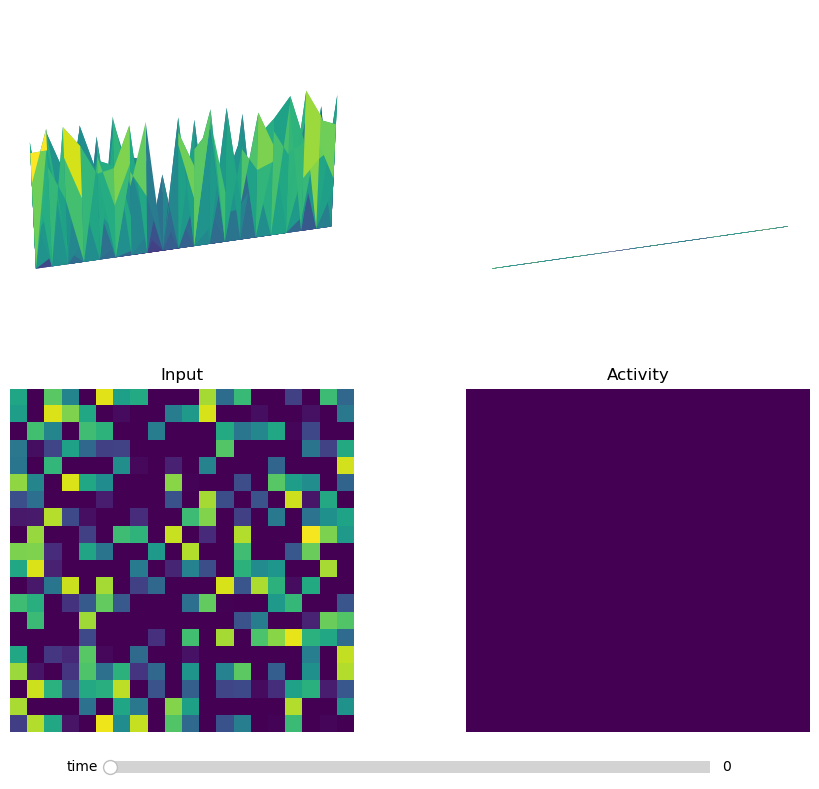

In [ ]:
#Inp.shape
wta2d.show_2d(xs, Inp, aa)

## 6. Export GIF (optional)

Requires `imageio`. Saves a short animated GIF of the activity.

In [26]:
import imageio
try:
    wta2d.save_gif(xs, aa, 'wta2d_activity.gif', nframe=30, delay=0.1)
    print('Saved Examples/wta2d_activity.gif')
except ImportError as e:
    print('GIF export needs imageio:', e)

Saved wta2d_activity.gif
